Из-за того, что vscode запущен от пользователя user, не все команды возможно выполнить в ячейках, так как часть команд требует прав пользователя devops или интерактивного sudo, поэтому часть команд я выполняю в терминале от пользователя devops. 

### Задание 1: Управление пользователями и привилегиями


Выполнено в терминале  
sudo adduser devops   
```(.venv) (base) user@Ubuntu-desktop:~/vs_code/devops2_hw$ sudo adduser devops  
Новый пароль:   
Повторите ввод нового пароля:   
passwd: пароль успешно обновлён  
Изменение информации о пользователе devops  
Введите новое значение или нажмите ENTER для выбора значения по умолчанию  
        Полное имя []: Devops2  
        Номер комнаты []:   
        Рабочий телефон []:   
        Домашний телефон []:   
        Другое []:   
ÐÐ°Ð½Ð½Ð°Ñ Ð¸Ð½Ñ  
                Ð¾ÑÐ¼Ð°ÑÐ¸Ñ ÐºÐ¾ÑÑÐµÐºÑÐ½Ð°? [Y/n] Y  
(.venv) (base) user@Ubuntu-desktop:~/vs_code/devops2_hw$   
```


Выполнено в терминале  
sudo usermod -aG sudo devops


In [38]:
%%bash
getent passwd devops

devops:x:1001:1001:Devops2,,,:/home/devops:/bin/bash


In [39]:
%%bash
groups devops

devops : devops sudo users docker


### Задание 2: Генерация SSH-ключа

Выполнено в терминале
sh-keygen -t rsa -b 4096

```
devops@Ubuntu-desktop:~$ ssh-keygen -t rsa -b 4096
Generating public/private rsa key pair.
Enter file in which to save the key (/home/devops/.ssh/id_rsa): 
Created directory '/home/devops/.ssh'.
Enter passphrase for "/home/devops/.ssh/id_rsa" (empty for no passphrase): 
Enter same passphrase again: 
Your identification has been saved in /home/devops/.ssh/id_rsa
Your public key has been saved in /home/devops/.ssh/id_rsa.pub
The key fingerprint is:
SHA256:MRkIKYlurSY2zkn/dAEvHp+fwpNzJVvN+7nzjjHs73c devops@Ubuntu-desktop
The key's randomart image is:
+---[RSA 4096]----+
| . ..o ..        |
|. o . .  o       |
|. .. .  +        |
| o .  o  o       |
|. .  o oS   o    |
|.*  . + o. o +   |
|B +  o.+. =   =  |
| + .. .*.o.  o =E|
|    ..  =o    +B@|
+----[SHA256]-----+
```

Выполнено в терминале  
cat ~/.ssh/id_rsa.pub
```
ssh-rsa AAAAB3NzaC1yc2EAAAADAQABAAACAQCzQBxQR2HlOw0ShPnMdB5kbQstEJQpV/V/M7WmTVczKuklQ6z6FIJiC6wcs0l7mmULShsZvcY/6uIcwrvtL01OOdhvSW6FFRPYIZ7fx2o8qNW54Qvhk811QSocJWgqa7BsUlrpZgkoMG1beyaYa6TpnbNlhgW110emRaTbae2zazzS716zbA6FER5uiJ7hIG5aZsCsnyQbLAI3f02/xHEUPXGAj/JY7ccf3lW79gnY8QK4iwaaJEF1ETUtTygKCNwOylokJAXLEAXp9k0OrprycWV2TlvRuoUm4ex5lmGm7poMx7TUvWdl2ahyZeTWvLrulMvXtVDqHMYnqZ9qG98dhwx5BBnmgk9u2Yh/pKVRWwDCEKF9yWT5NzXoNknpIybLDgcEGZTld3F95jpOXy0at/oVX1XfHg1Xd30m8PaEFv1ZOqZwuz0/a0B1SB8Aj19tgZYUcVl8I5rSsUiC3ij9MdHO9uuoN5ZsFR/+Q2xQPf8POuac1UJSypZP9VFlW9elnxoYF8yEUmPv/fVhZZHjkxMQhPXRDyuotNNprnUTP0MwW/RrCegVlnlcYj+YRx1QXnHUS3g/B9KZM1SDJPnsEp2eHEOBXX57IHm/KvrxQ8rOGoyIYroVAoqJBJs0TFYUjyBmRUGzopPWfDd2SJYXuk9hygqEG5YEuewlAfI9/w== devops@Ubuntu-desktop
```

### Задание 3: Работа с процессами и сетевыми соединениями

Сначала выведем список всех процессов, запущенных от имени пользователя devops, в полном формате

In [17]:
%%bash
ps -f -u devops

UID          PID    PPID  C STIME TTY          TIME CMD
devops     35363       1  0 10:54 ?        00:00:00 /usr/lib/systemd/systemd --user
devops     35366   35363  0 10:54 ?        00:00:00 (sd-pam)
devops     35386   35352  0 10:54 pts/0    00:00:00 -bash
devops     35387   35363  0 10:54 ?        00:00:00 /usr/bin/dbus-daemon --session --address=systemd: --nofork --nopidfile --systemd-activation --syslog-only
devops     35388   35363  0 10:54 ?        00:00:00 /usr/bin/pipewire
devops     35392   35363  0 10:54 ?        00:00:00 /snap/snapd-desktop-integration/361/usr/bin/snapd-desktop-integration
devops     35422   35363  0 10:54 ?        00:00:00 /usr/bin/mpris-proxy
devops     35424   35363  0 10:54 ?        00:00:00 /usr/bin/wireplumber
devops     35428   35363  0 10:54 ?        00:00:00 /usr/bin/pipewire -c filter-chain.conf
devops     35429   35363  0 10:54 ?        00:00:00 /usr/bin/pipewire-pulse
devops     35517   35363  0 10:54 ?        00:00:00 /usr/libexec/xdg-document-

Здесь выведем все прослушиваемые TCP-порты в системе с указанием PID и имени программы, которая их использует

```
Выполнено в терминале  
sudo ss -l -t -n -p

devops@Ubuntu-desktop:~$ sudo ss -l -t -n -p
State           Recv-Q          Send-Q                   Local Address:Port                    Peer Address:Port         Process                                             
LISTEN          0               100                          127.0.0.1:42501                        0.0.0.0:*             users:(("python",pid=43136,fd=30))                 
LISTEN          0               4096                         127.0.0.1:32967                        0.0.0.0:*             users:(("containerd",pid=1233,fd=14))              
LISTEN          0               4096                        127.0.0.54:53                           0.0.0.0:*             users:(("systemd-resolve",pid=388,fd=19))          
LISTEN          0               4096                     127.0.0.53%lo:53                           0.0.0.0:*             users:(("systemd-resolve",pid=388,fd=17))          
LISTEN          0               4096                         127.0.0.1:631                          0.0.0.0:*             users:(("cupsd",pid=46069,fd=7))                   
LISTEN          0               511                          127.0.0.1:33759                        0.0.0.0:*             users:(("code",pid=42303,fd=48))                   
LISTEN          0               100                          127.0.0.1:9004                         0.0.0.0:*             users:(("python",pid=43136,fd=25))                 
LISTEN          0               100                          127.0.0.1:9000                         0.0.0.0:*             users:(("python",pid=43136,fd=43))                 
LISTEN          0               100                          127.0.0.1:9001                         0.0.0.0:*             users:(("python",pid=43136,fd=13))                 
LISTEN          0               100                          127.0.0.1:9002                         0.0.0.0:*             users:(("python",pid=43136,fd=9))                  
LISTEN          0               100                          127.0.0.1:9003                         0.0.0.0:*             users:(("python",pid=43136,fd=11))                 
LISTEN          0               511                          127.0.0.1:35599                        0.0.0.0:*             users:(("code",pid=43063,fd=43))                   
LISTEN          0               4096                             [::1]:631                             [::]:*             users:(("cupsd",pid=46069,fd=6))                   
devops@Ubuntu-desktop:~$ 
```

### Задание 4: Установка и базовая настройка Docker

Докер уже был установлен ранее

In [24]:
%%bash
docker --version

Docker version 29.1.3, build 29.1.3-0ubuntu4.1



Выполнено в терминале
sudo gpasswd -a devops docker
```
devops@Ubuntu-desktop:~$ sudo gpasswd -a devops docker
Добавление пользователя devops в группу docker
```

Проверим, что все добавилось

In [25]:
%%bash
groups devops

devops : devops sudo users docker


Включим автоматический запуск службы Docker при старте системы и запустим её


Выполнено в терминале
sudo systemctl enable --now docker.service
```
devops@Ubuntu-desktop:~$ sudo systemctl enable --now docker.service
```

Проверим статус службы Docker

In [26]:
%%bash
systemctl status docker.service

● docker.service - Docker Application Container Engine
     Loaded: loaded (/usr/lib/systemd/system/docker.service; enabled; preset: enabled)
     Active: active (running) since Mon 2026-09-14 22:51:14 +04; 3 weeks 0 days ago
 Invocation: 5248c3d6058b4b67a6afe378b8674e55
TriggeredBy: ● docker.socket
       Docs: https://docs.docker.com
   Main PID: 1341 (dockerd)
      Tasks: 9
     Memory: 47M (peak: 109.8M, swap: 10.2M, swap peak: 21M)
        CPU: 4.368s
     CGroup: /system.slice/docker.service
             └─1341 /usr/bin/dockerd -H fd:// --containerd=/run/containerd/containerd.sock

сен 14 22:51:13 Ubuntu-desktop dockerd[1341]: time="2026-09-14T22:51:13.009344640+04:00" level=info msg="Restoring containers: start."
сен 14 22:51:13 Ubuntu-desktop dockerd[1341]: time="2026-09-14T22:51:13.078309128+04:00" level=info msg="Deleting nftables IPv4 rules" error="exit status 1"
сен 14 22:51:13 Ubuntu-desktop dockerd[1341]: time="2026-09-14T22:51:13.109121919+04:00" level=info msg="Deletin

### Задание 5: Отладка и диагностика TLS-сертификата

#### Запуск скрипта prepare_letsencrypt.sh

Сейчас наш prepare_letsencrypt.sh лежит в папке для пользователя user, перенесем этот файл в папку к пользователю devops

Выполнила в терминале от пользователя user  
```
sudo cp /home/user/vs_code/devops2_hw/DevOps2/prepare_letsencrypt.sh /home/devops/  
sudo chown devops:devops /home/devops/prepare_letsencrypt.sh
```
Выполнила в терминале от пользователя devops

```
devops@Ubuntu-desktop:~$ ls -l prepare_letsencrypt.sh
-rwxr-x--- 1 devops devops 3363 Oct  6 15:09 prepare_letsencrypt.sh
devops@Ubuntu-desktop:~$ ./prepare_letsencrypt.sh
=== Подготовка окружения для Let's Encrypt ===
Установка Certbot...
Сущ:1 http://ru.archive.ubuntu.com/ubuntu resolute InRelease
Пол:2 http://ru.archive.ubuntu.com/ubuntu resolute-updates InRelease [137 kB]                                                                                               
Сущ:3 http://ru.archive.ubuntu.com/ubuntu resolute-backports InRelease                                                                                                      
Пол:4 http://ru.archive.ubuntu.com/ubuntu resolute-updates/universe amd64 Packages [320 kB]                                                                                 
Пол:5 https://dl.google.com/linux/chrome-stable/deb stable InRelease [2 548 B]                                                                                              
Пол:6 https://dl.google.com/linux/chrome-stable/deb stable/main amd64 Packages [1 412 B]                                                                                  
Пол:7 http://security.ubuntu.com/ubuntu resolute-security InRelease [137 kB]                                                                   
Сущ:8 https://packages.microsoft.com/repos/code stable InRelease                                         
Пол:9 http://security.ubuntu.com/ubuntu resolute-security/main amd64 Packages [562 kB]
Пол:10 http://security.ubuntu.com/ubuntu resolute-security/main Translation-en [132 kB]
Получено 1 293 kB за 2с (630 kB/s)         
Может быть обновлено 62 пакета. Запустите «apt list --upgradable» для их показа.
Установка:                                                        
  certbot

Установка зависимостей:
  python3-acme  python3-certbot  python3-configargparse  python3-icu  python3-josepy  python3-openssl  python3-parsedatetime  python3-pytz  python3-rfc3339

Предлагаемые пакеты:
  python-certbot-doc  python3-certbot-apache  python3-certbot-nginx  python-acme-doc  python-openssl-doc

Сводка:
  Обновление: 0, Установка: 10, Удаление: 0, Пропуск обновления: 62
  Объём загрузки: 1 227 kB
  Требуемое пространство: 6 260 kB / 21,7 GB доступно

Пол:1 http://ru.archive.ubuntu.com/ubuntu resolute/main amd64 python3-openssl all 25.3.0-1ubuntu1 [46,4 kB]
Пол:2 http://ru.archive.ubuntu.com/ubuntu resolute/universe amd64 python3-josepy all 2.2.0-1 [22,3 kB]
Пол:3 http://ru.archive.ubuntu.com/ubuntu resolute/universe amd64 python3-pytz all 2025.2-5 [32,4 kB]
Пол:4 http://ru.archive.ubuntu.com/ubuntu resolute/universe amd64 python3-rfc3339 all 2.0.1-2 [6 530 B]
Пол:5 http://ru.archive.ubuntu.com/ubuntu resolute/universe amd64 python3-acme all 4.0.0-2 [49,3 kB]
Пол:6 http://ru.archive.ubuntu.com/ubuntu resolute/main amd64 python3-configargparse all 1.7-2 [31,7 kB]
Пол:7 http://ru.archive.ubuntu.com/ubuntu resolute/universe amd64 python3-parsedatetime all 2.6-3build1 [32,1 kB]
Пол:8 http://ru.archive.ubuntu.com/ubuntu resolute/universe amd64 python3-certbot all 4.0.0-4 [267 kB]
Пол:9 http://ru.archive.ubuntu.com/ubuntu resolute/main amd64 python3-icu amd64 2.16.1-1build1 [647 kB]
Пол:10 http://ru.archive.ubuntu.com/ubuntu resolute/universe amd64 certbot all 4.0.0-4 [91,5 kB]
Получено 1 227 kB за 2с (522 kB/s)         
debconf: не удалось инициализировать интерфейс: Dialog
debconf: (Для интерфейса dialog требуется экран не менее 13 строк в высоту и 31 колонки в ширину.)
debconf: будет использован интерфейс: Readline
Предварительная настройка пакетов …
Выбор ранее не выбранного пакета python3-openssl.
(Чтение базы данных … на данный момент установлено 234280 файлов и каталогов.)
Подготовка к распаковке …/0-python3-openssl_25.3.0-1ubuntu1_all.deb …
Распаковывается python3-openssl (25.3.0-1ubuntu1) …
Выбор ранее не выбранного пакета python3-josepy.
Подготовка к распаковке …/1-python3-josepy_2.2.0-1_all.deb …
Распаковывается python3-josepy (2.2.0-1) …
Выбор ранее не выбранного пакета python3-pytz.
Подготовка к распаковке …/2-python3-pytz_2025.2-5_all.deb …
Распаковывается python3-pytz (2025.2-5) …
Выбор ранее не выбранного пакета python3-rfc3339.
Подготовка к распаковке …/3-python3-rfc3339_2.0.1-2_all.deb …
Распаковывается python3-rfc3339 (2.0.1-2) …
Выбор ранее не выбранного пакета python3-acme.
Подготовка к распаковке …/4-python3-acme_4.0.0-2_all.deb …
Распаковывается python3-acme (4.0.0-2) …
Выбор ранее не выбранного пакета python3-configargparse.
Подготовка к распаковке …/5-python3-configargparse_1.7-2_all.deb …
Распаковывается python3-configargparse (1.7-2) …
Выбор ранее не выбранного пакета python3-parsedatetime.
Подготовка к распаковке …/6-python3-parsedatetime_2.6-3build1_all.deb …
Распаковывается python3-parsedatetime (2.6-3build1) …
Выбор ранее не выбранного пакета python3-certbot.
Подготовка к распаковке …/7-python3-certbot_4.0.0-4_all.deb …
Распаковывается python3-certbot (4.0.0-4) …
Выбор ранее не выбранного пакета python3-icu.
Подготовка к распаковке …/8-python3-icu_2.16.1-1build1_amd64.deb …
Распаковывается python3-icu (2.16.1-1build1) …
Выбор ранее не выбранного пакета certbot.
Подготовка к распаковке …/9-certbot_4.0.0-4_all.deb …
Распаковывается certbot (4.0.0-4) …
Настраивается пакет python3-configargparse (1.7-2) …
Настраивается пакет python3-parsedatetime (2.6-3build1) …
Настраивается пакет python3-icu (2.16.1-1build1) …
Настраивается пакет python3-openssl (25.3.0-1ubuntu1) …
Настраивается пакет python3-pytz (2025.2-5) …
Настраивается пакет python3-josepy (2.2.0-1) …
Настраивается пакет python3-rfc3339 (2.0.1-2) …
Настраивается пакет python3-acme (4.0.0-2) …
Настраивается пакет python3-certbot (4.0.0-4) …
Настраивается пакет certbot (4.0.0-4) …
Created symlink '/etc/systemd/system/timers.target.wants/certbot.timer' → '/usr/lib/systemd/system/certbot.timer'.
Обрабатываются триггеры для man-db (2.13.1-1build1) …
Настройка локального домена myserver.local...
127.0.0.1 myserver.local
Создание директории с веб-контентом...
<html><body><h1>It works!</h1></body></html>
Запуск Nginx в Docker-контейнере...
Unable to find image 'nginx:alpine' locally
alpine: Pulling from library/nginx
e72112c14215: Pull complete 
e2de96513ba9: Pull complete 
d9aae54b5831: Pull complete 
6c53d0b2a666: Pull complete 
745dfb2690dd: Pull complete 
64c8194480fe: Pull complete 
e76228b47809: Pull complete 
9a9a644fdd6a: Pull complete 
0deea27e58d9: Download complete 
d54d3939625e: Download complete 
Digest: sha256:df221db836e1754089190208cee7eeda94f233197056426eda74a43ab1abeac2
Status: Downloaded newer image for nginx:alpine
2a6e97157e5ca4a6c61f0438cf440379900285f839b5a136f6b13f9ef8194373
Ожидание запуска контейнера...
Проверка статуса контейнера...
NAMES               STATUS         PORTS
nginx-letsencrypt   Up 3 seconds   0.0.0.0:80->80/tcp, [::]:80->80/tcp
Проверка доступности веб-сервера...
./prepare_letsencrypt.sh: строка 61: curl: command not found
Предупреждение: веб-сервер не отвечает. Проверьте логи: docker logs nginx-letsencrypt

=== Подготовка завершена ===
Домен myserver.local настроен и доступен по адресу http://myserver.local
Nginx запущен в контейнере: nginx-letsencrypt

Теперь можно приступать к выполнению задания 5.
Для просмотра логов контейнера используйте: docker logs nginx-letsencrypt
```

#### Шаг 1: Проверьте доступность веб-сервера локально по адресу http://myserver.local

In [36]:
%%bash
curl -i http://myserver.local

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    45  100    45    0     0   8359      0 --:--:-- --:--:-- --:--:--  9000


HTTP/1.1 200 OK
Server: nginx/1.31.6
Date: Tue, 06 Oct 2026 11:46:37 GMT
Content-Type: text/html
Content-Length: 45
Last-Modified: Tue, 06 Oct 2026 11:21:11 GMT
Connection: keep-alive
ETag: "6ac4d9a7-2d"
Accept-Ranges: bytes

<html><body><h1>It works!</h1></body></html>


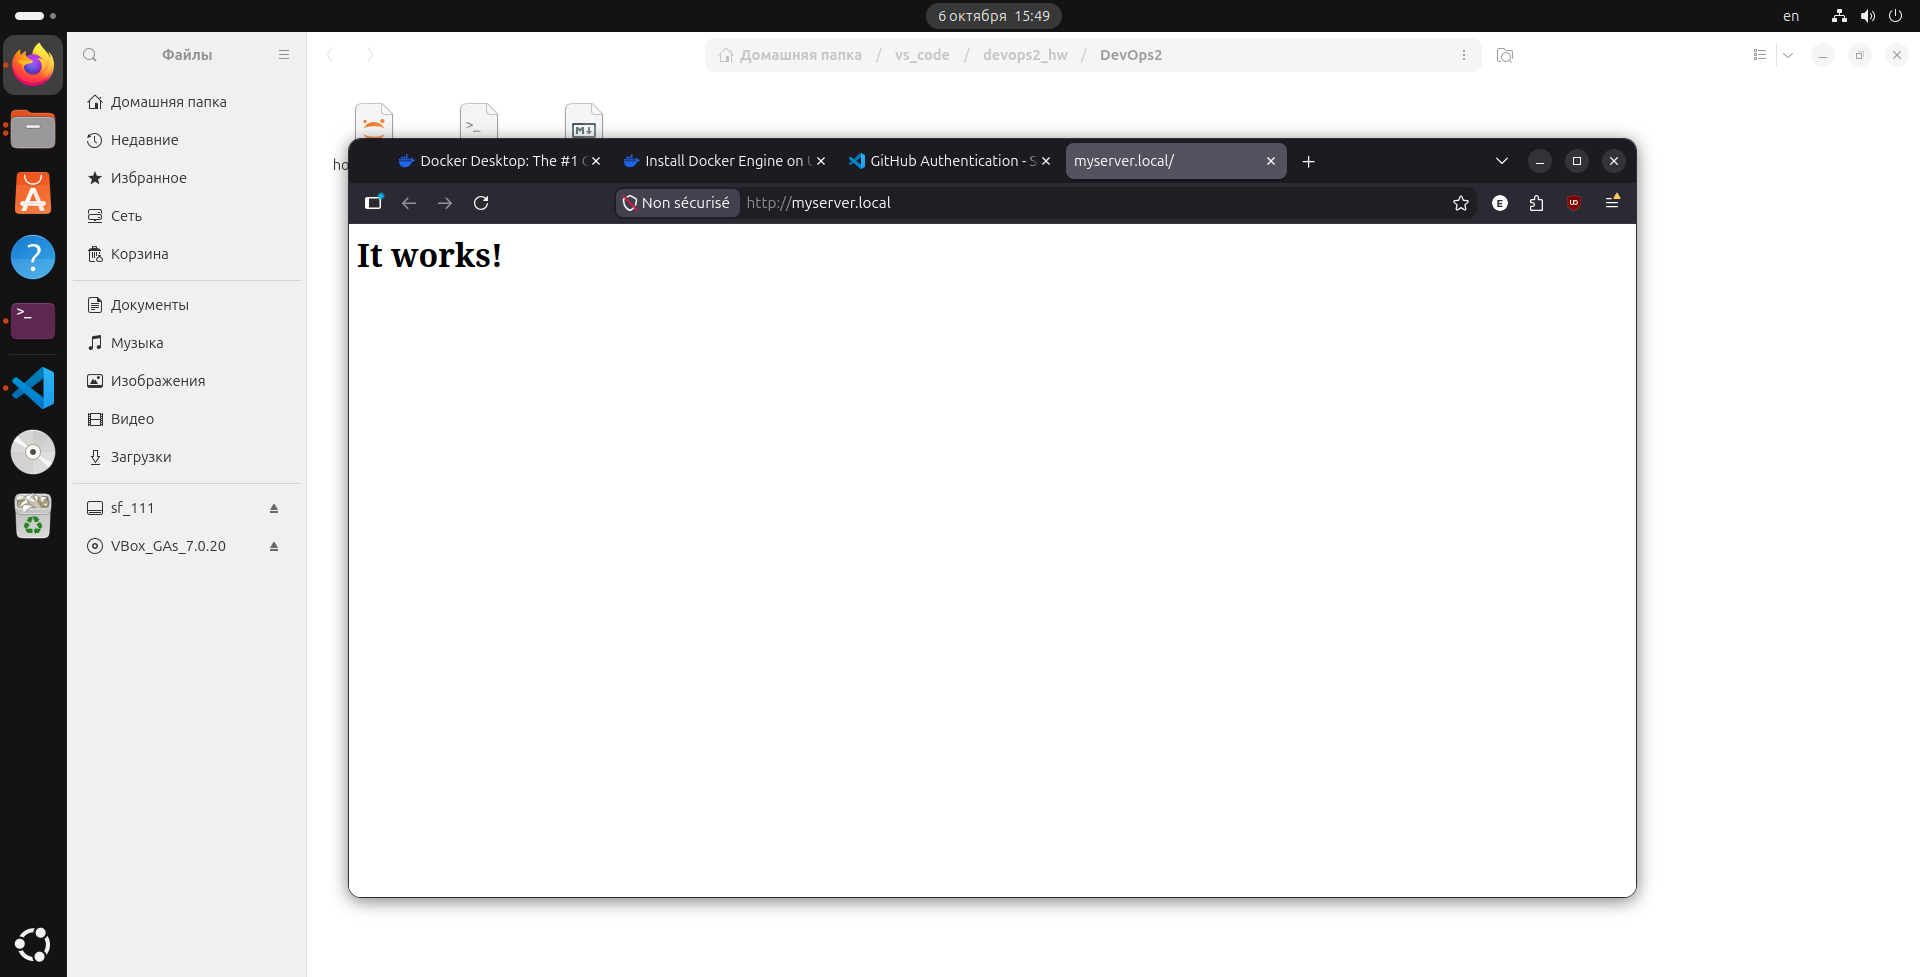

#### Шаг 2: Определите, какие порты слушает контейнер с Nginx на хостовой системе

Выполнила в терминале docker ps
```
devops@Ubuntu-desktop:~$ docker ps
CONTAINER ID   IMAGE          COMMAND                  CREATED          STATUS          PORTS                                 NAMES
2a6e97157e5c   nginx:alpine   "/docker-entrypoint.…"   47 minutes ago   Up 47 minutes   0.0.0.0:80->80/tcp, [::]:80->80/tcp   nginx-letsencrypt
```

#### Шаг 3: Проверьте логи контейнера с Nginx на наличие ошибок

Выполнила в терминале docker logs 2a6e97157e5c  
ID контейнера взяла из вывода от прошлой команды

```
devops@Ubuntu-desktop:~$ docker logs 2a6e97157e5c
/docker-entrypoint.sh: /docker-entrypoint.d/ is not empty, will attempt to perform configuration
/docker-entrypoint.sh: Looking for shell scripts in /docker-entrypoint.d/
/docker-entrypoint.sh: Launching /docker-entrypoint.d/10-listen-on-ipv6-by-default.sh
10-listen-on-ipv6-by-default.sh: info: Getting the checksum of /etc/nginx/conf.d/default.conf
10-listen-on-ipv6-by-default.sh: info: Enabled listen on IPv6 in /etc/nginx/conf.d/default.conf
/docker-entrypoint.sh: Sourcing /docker-entrypoint.d/15-local-resolvers.envsh
/docker-entrypoint.sh: Launching /docker-entrypoint.d/20-envsubst-on-templates.sh
/docker-entrypoint.sh: Launching /docker-entrypoint.d/30-tune-worker-processes.sh
/docker-entrypoint.sh: Configuration complete; ready for start up
2026/10/06 11:21:25 [notice] 1#1: using the "epoll" event method
2026/10/06 11:21:25 [notice] 1#1: nginx/1.31.6
2026/10/06 11:21:25 [notice] 1#1: built by gcc 15.2.0 (Alpine 15.2.0) 
2026/10/06 11:21:25 [notice] 1#1: OS: Linux 7.0.0-31-generic
2026/10/06 11:21:25 [notice] 1#1: getrlimit(RLIMIT_NOFILE): 1024:524288
2026/10/06 11:21:25 [notice] 1#1: start worker processes
2026/10/06 11:21:25 [notice] 1#1: start worker process 30
2026/10/06 11:21:25 [notice] 1#1: start worker process 31
172.17.0.1 - - [06/Oct/2026:11:38:26 +0000] "GET / HTTP/1.1" 200 45 "-" "Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:155.0) Gecko/20100101 Firefox/155.0" "-"
172.17.0.1 - - [06/Oct/2026:11:38:26 +0000] "GET /favicon.ico HTTP/1.1" 404 153 "http://myserver.local/" "Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:155.0) Gecko/20100101 Firefox/155.0" "-"
2026/10/06 11:38:26 [error] 30#30: *1 open() "/usr/share/nginx/html/favicon.ico" failed (2: No such file or directory), client: 172.17.0.1, server: localhost, request: "GET /favicon.ico HTTP/1.1", host: "myserver.local", referrer: "http://myserver.local/"
172.17.0.1 - - [06/Oct/2026:11:46:37 +0000] "GET / HTTP/1.1" 200 45 "-" "curl/8.16.0" "-"
```

В выводе есть ошибка, но она никак не влияет на работоспособность веб-сервера, это ошибка иконки сайта favicon.ico, Nginx не нашел такой файл и поэтому вернул ошибку

#### Шаг 4: Проверьте, есть ли в системе уже установленные TLS-сертификаты для данного домена

Выполнила в терминале sudo certbot certificates
```
devops@Ubuntu-desktop:~$ sudo certbot certificates
Saving debug log to /var/log/letsencrypt/letsencrypt.log

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
No certificates found.
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
```

#### Шаг 5: Сгенерируйте сертификат для домена myserver.local.

Выполнила в терминале   
openssl req -x509 -newkey rsa:2048 -nodes -days 365 \   
  -subj "/CN=myserver.local" \   
  -addext "subjectAltName=DNS:myserver.local" \   
  -keyout myserver.key \   
  -out myserver.crt   
```
devops@Ubuntu-desktop:~$ openssl req -x509 -newkey rsa:2048 -nodes -days 365 \
  -subj "/CN=myserver.local" \
  -addext "subjectAltName=DNS:myserver.local" \
  -keyout myserver.key \
  -out myserver.crt
...+.................+.+.....+.......+..+.+......+.....+.+.........+.....+...+.......+++++++++++++++++++++++++++++++++++++++*..+.+...+..+.+..+++++++++++++++++++++++++++++++++++++++*......+...+...+.+........+......+......+.+.....+....+...+..+.+........+......+.+.....+.......+...............+.....+.+............++++++
.+......+..+++++++++++++++++++++++++++++++++++++++*...+....+...+.....+.............+...............+++++++++++++++++++++++++++++++++++++++*......+.......+............+......+......+...+......+..++++++
-----
```
Закрыла от всех приватный ключ, кроме владельца  
devops@Ubuntu-desktop:~$ chmod 600 myserver.key

#### Шаг 6: Убедитесь, что файлы сертификата созданы в соответствующей директории

Выполнено в терминале  
```
devops@Ubuntu-desktop:~$ pwd
ls -l myserver.crt myserver.key
/home/devops
-rw-rw-r-- 1 devops devops 1164 Oct  6 16:48 myserver.crt
-rw------- 1 devops devops 1704 Oct  6 16:48 myserver.key
```
сертификаты в нужной папке /home/devops

#### Шаг 7: Просмотрите информацию о полученном сертификате (издатель, срок действия, алгоритм)

Выполнено в терминале  
Издатель и срок действия
```
devops@Ubuntu-desktop:~$ openssl x509 -in myserver.crt \
  -noout -subject -issuer -dates -ext subjectAltName
subject=CN=myserver.local
issuer=CN=myserver.local
notBefore=Oct  6 12:48:11 2026 GMT
notAfter=Oct  6 12:48:11 2027 GMT
X509v3 Subject Alternative Name: 
    DNS:myserver.local

```


Выполнено в терминале  
Алгоритм
```
evops@Ubuntu-desktop:~$ openssl x509 -in myserver.crt -noout -text | grep -E "Signature Algorithm|Public Key Algorithm"
        Signature Algorithm: sha256WithRSAEncryption
            Public Key Algorithm: rsaEncryption
    Signature Algorithm: sha256WithRSAEncryption
```

#### Шаг 8: Проверьте точные даты начала и окончания действия сертификата

Выполнено в терминале  
```
devops@Ubuntu-desktop:~$ openssl x509 -in myserver.crt -noout -startdate -enddate
notBefore=Oct  6 12:48:11 2026 GMT
notAfter=Oct  6 12:48:11 2027 GMT
```